## Step 3: Data Preprocessing

Raw images cannot be directly used for model training. Preprocessing is required to standardize inputs and improve learning efficiency.

The objectives of this step are:

* Resize images to a fixed resolution
* Normalize pixel values
* Convert masks into binary format
* Prepare data in a format suitable for model training

This step ensures consistency across inputs and enables effective feature learning.


In [43]:
#  Import required libraries

import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [44]:
# Load balanced dataset

df = pd.read_csv("/kaggle/input/datasets/sairasagnak/balanced-data-rsna/balanced_data.csv")

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (12024, 8)


,patientId,Target,class,age,sex,position,image_path,mask_path
0,bbd7abfe-8b9c-46aa-ab4b-8ff854615770,1,Lung Opacity,50,F,AP,/kaggle/input/datasets/iamtapendu/rsna-pneumon...,/kaggle/input/datasets/iamtapendu/rsna-pneumon...
1,9f3c08be-0b3a-413d-aade-4bc74cee30b7,0,Normal,75,F,PA,/kaggle/input/datasets/iamtapendu/rsna-pneumon...,/kaggle/input/datasets/iamtapendu/rsna-pneumon...
2,579c68e7-c03e-4cd7-bda5-93de372571f2,0,Normal,21,M,PA,/kaggle/input/datasets/iamtapendu/rsna-pneumon...,/kaggle/input/datasets/iamtapendu/rsna-pneumon...
3,51ad4587-85e0-40c0-9683-befde300818f,0,No Lung Opacity / Not Normal,72,F,PA,/kaggle/input/datasets/iamtapendu/rsna-pneumon...,/kaggle/input/datasets/iamtapendu/rsna-pneumon...
4,a863ad50-b68a-4e28-8934-b3fe0b89cefc,0,Normal,52,F,PA,/kaggle/input/datasets/iamtapendu/rsna-pneumon...,/kaggle/input/datasets/iamtapendu/rsna-pneumon...


In [45]:
# Fix image and mask paths for Kaggle

DATA_DIR = "/kaggle/input/datasets/iamtapendu/rsna-pneumonia-processed-dataset"

IMAGE_DIR = os.path.join(DATA_DIR, "Training", "Images")
MASK_DIR = os.path.join(DATA_DIR, "Training", "Masks")

df['image_path'] = df['patientId'].apply(lambda x: os.path.join(IMAGE_DIR, x + ".png"))
df['mask_path'] = df['patientId'].apply(lambda x: os.path.join(MASK_DIR, x + ".png"))

In [46]:
#  Build paths dynamically (handle extension issues)

def get_image_path(pid):
    png_path = os.path.join(IMAGE_DIR, pid + ".png")
    jpg_path = os.path.join(IMAGE_DIR, pid + ".jpg")
    
    if os.path.exists(png_path):
        return png_path
    elif os.path.exists(jpg_path):
        return jpg_path
    else:
        return None

def get_mask_path(pid):
    png_path = os.path.join(MASK_DIR, pid + ".png")
    
    if os.path.exists(png_path):
        return png_path
    else:
        return None

df['image_path'] = df['patientId'].apply(get_image_path)
df['mask_path'] = df['patientId'].apply(get_mask_path)

In [47]:
# Filter valid samples only

df = df[df['image_path'].notnull()].reset_index(drop=True)

print("After filtering:", df.shape)

After filtering: (12024, 8)


In [48]:
#  Define preprocessing functions

IMG_SIZE = 224

def preprocess_image(path):
    img = cv2.imread(path, 0)
    if img is None:
        return None
    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
    img = img / 255.0
    return img

def preprocess_mask(path):
    mask = cv2.imread(path, 0)
    if mask is None:
        return None
    mask = cv2.resize(mask, (IMG_SIZE, IMG_SIZE))
    mask = (mask > 0).astype(np.float32)
    return mask

In [49]:
#  Test preprocessing on small batch

images = []
labels = []

subset = df.sample(min(5, len(df)), random_state=42)

for _, row in subset.iterrows():
    img = preprocess_image(row['image_path'])
    
    if img is None:
        continue
    
    images.append(img)
    labels.append(row['Target'])

images = np.array(images)
labels = np.array(labels)

print("Images shape:", images.shape)
print("Labels shape:", labels.shape)

Images shape: (5, 224, 224)
Labels shape: (5,)


(np.float64(-0.5), np.float64(223.5), np.float64(223.5), np.float64(-0.5))

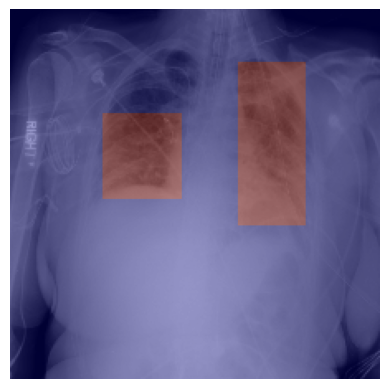

In [50]:
#  Visualize processed image and mask

row = df.iloc[0]

img = preprocess_image(row['image_path'])
mask = preprocess_mask(row['mask_path'])

plt.imshow(img, cmap='gray')
plt.imshow(mask, cmap='jet', alpha=0.4)
plt.axis('off')

## Step 3: Observations

* All images were successfully resized to a uniform resolution of 224×224, ensuring consistent input dimensions for model training.
* Pixel values were normalized to the range [0, 1], improving numerical stability during training.
* Segmentation masks were converted into binary format, accurately highlighting regions of pneumonia.
* Dataset filtering ensured that only valid image paths were retained, preventing runtime errors and improving data quality.
* The preprocessing pipeline was validated on a sample subset, confirming correct transformation and alignment between images and masks.

These preprocessing steps establish a reliable and standardized data pipeline, which is essential for effective feature learning and model performance.
